# Analyzing Chicken Vocalizations with VAD

In [1]:
# Goal: Practice using energy-based threshold Voice Activity Detection (VAD) to separate and extract features
# from animal vocalizations

# Audio used:
# -	Chicken egg song (personal recording)
# - Sperm whale conversation exchanging 1+1+3 coda's from Eastern Caribbean clan (Dominica Sperm Whale Project)

# Date last updated: 1/20/2025
# Author: Kay Rubio

In [1]:
# Check python version and compatibility with Librosa
!python3 --version

Python 3.12.8


In [288]:
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display
import IPython.display as ipd
from IPython.display import Audio
import soundfile as sf
from vad import EnergyVAD
import pandas as pd

In [108]:
# Load audio with Librosa.load which automatically resamples at sr=22050
audio_folder = "Sounds/sample_audios/"
# chicken egg song ~13sec
chicken, sr = librosa.load(audio_folder+"chicken.wav")
# sperm whale codas ~1min
spermwhale, _ = librosa.load(audio_folder+"spermwhale1+1+3.wav")

In [7]:
# Use librosa default sampling rate throughout project
SR = sr

## Helper Methods

In [307]:
# Function to plot a waveform with title and optional section highlights based on timestamps
def plotWaveform(audio, title, sections=[], sections2=[]):
    plt.figure(figsize=(10, 4))
    librosa.display.waveshow(audio, sr=SR, alpha=0.5, color='blue')
    plt.title(title)
    plt.xlabel("Time (sec)") 
    plt.ylabel("Amplitude")
    for section in sections:
        start, end = float(section['start']), float(section['end'])
        plt.axvspan(start, end, color='purple', alpha=0.3)
    for section in sections2:
        start, end = float(section['start']), float(section['end'])
        plt.axvspan(start, end, color='yellow', alpha=0.3)
    plt.show()

In [272]:
# Function that will loop through all the frames, and if they are consecutive 1's or 0's, lump them 
# together as one section, and find the timestamps that correspond to the first frame and last frame in 
# each section
# arguments:
#    vad_output in format [0, 0, 1, 1, ...] where each 1 = a frame with sound, 0 = frame with silence
#    frame_length
#    frame_shift/hop_length
#    sound, where 1 will provide timestamps for the sounds, and 0 provides timestamps for the silences
# Returns an array of vocalizations, with elements in format {'start': time in seconds, 'end': time in seconds}

def convert_vad_output_to_timestamps(vad_output, frame_length, frame_shift, sound=1):
    sections = []
    sections_start = None

    # Loop through each frame in the VAD output
    for i, frame in enumerate(vad_output):
        # Calculate the start and end times of the current frame
        start_time = i * frame_shift / 1000  # Convert to seconds
        end_time = start_time + frame_length / 1000  # Convert to seconds

        if frame == sound:
            if sections_start is None:
                # Vocals starts here
                sections_start = start_time
        else:
            if sections_start is not None:
                # Vocals ends here
                sections.append({
                    'start': f"{sections_start:.3f}",
                    'end': f"{end_time:.3f}"
                })
                sections_start = None

    # Handle the case if the last frame has speech
    if sections_start is not None:
        sections.append({
            'start': f"{sections_start:.3f}",
            'end': f"{end_time:.3f}"
        })

    return sections

In [301]:
# Convert timestamps into durations
# Returns timestamps in format {'start': time in seconds, 'end': time in seconds}
def convert_timestamps_to_durations(timestamps):
    durations = []
    for i, timestamps in enumerate(timestamps):
        durations.append(round(float(timestamps['end'])-float(timestamps['start']), 4))
    return durations

In [103]:
# Function to spit an audio into an array of individual audios by timestamp.
# Assumes timestamps are in format {'start': time in seconds, 'end': time in seconds}
def splitAudioByTimestamps(audio, timestamps):
    audio_array = []
    for i, ts in enumerate(timestamps):
        start_sample = int(float(ts['start']) * SR) # convert start time into sample index
        end_sample = int(float(ts['end']) * SR)
        segment = audio[start_sample:end_sample] # Extract the segment using start and ending sample index
        audio_array.append(segment) # append segment into the array
    return audio_array

In [98]:
# Function to export an array of individual sounds (need to create a folder with matching foldername first)
def exportArrayOfAudio(array, foldername, filename):
    for i, sound in enumerate(array):
    	sf.write(f'{foldername}/{filename}{i}.wav', sound, SR)

## Use VAD to separate each chicken cluck

In [2]:
#ipd.Audio(audio_folder+"chicken.wav")

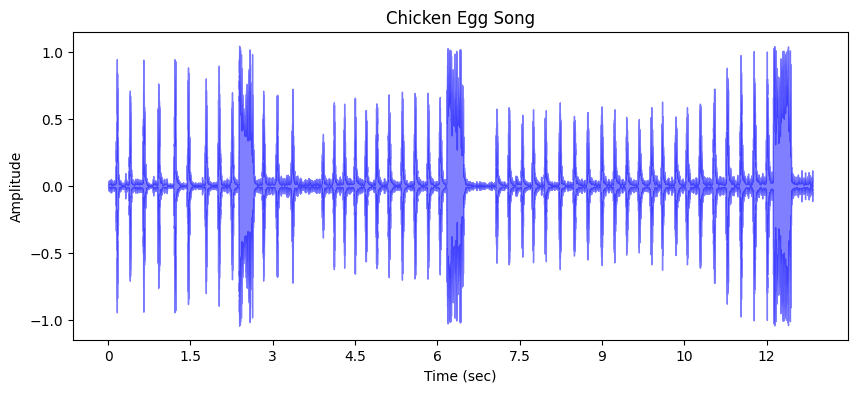

In [150]:
plotWaveform(chicken, 'Chicken Egg Song')

In [11]:
# Simple energy-based VAD to separate vocalizations into individual files and cut out silence

In [16]:
FRAME_LENGTH = 25 # in milliseconds
FRAME_SHIFT = 20 # in milliseconds, same concept as hop length
ENERGY_THRESHOLD = 0.05 # Energy above this threshold is classified as speech
PRE_EMPHASIS = 0.95 # Boost the energy of high-frequencies

In [17]:
vad = EnergyVAD(frame_length = FRAME_LENGTH, frame_shift = FRAME_SHIFT, sample_rate = SR, energy_threshold = ENERGY_THRESHOLD)

In [23]:
# array returned by VAD has one element per frame, and each element is a boolean indicating if above energy threshold or not
voice_activity_chicken = vad(chicken)
voice_activity_chicken[:10] # check first 10 values

array([0., 0., 0., 0., 0., 0., 1., 1., 1., 1.])

In [67]:
vocal_timestamps_chicken = convert_vad_output_to_timestamps(voice_activity_chicken, FRAME_LENGTH, FRAME_SHIFT)
vocal_timestamps_chicken[9] # check one of the long clucks

{'start': '2.360', 'end': '2.685'}

In [27]:
# I counted 48-ish individual clucks on the chicken egg song waveform, lets check the length of this array to
# see if that jives
len(vocal_timestamps_chicken)

49

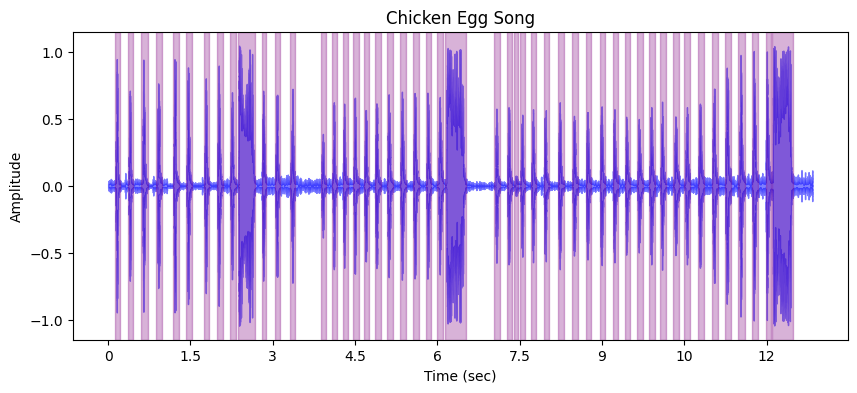

In [151]:
plotWaveform(chicken, 'Chicken Egg Song', vocal_timestamps_chicken)

In [104]:
# Use timestamps to split the chicken audio into 49 pieces, one for each vocalization
chicken_vocals = splitAudioByTimestamps(chicken, vocal_timestamps_chicken)
len(chicken_vocals)

49

In [105]:
# Check the number of samples in a longer cluck
len(chicken_vocals[9])

7166

In [3]:
# Play the audio signal directly
# Audio(data=chicken_vocals[9], rate=SR)

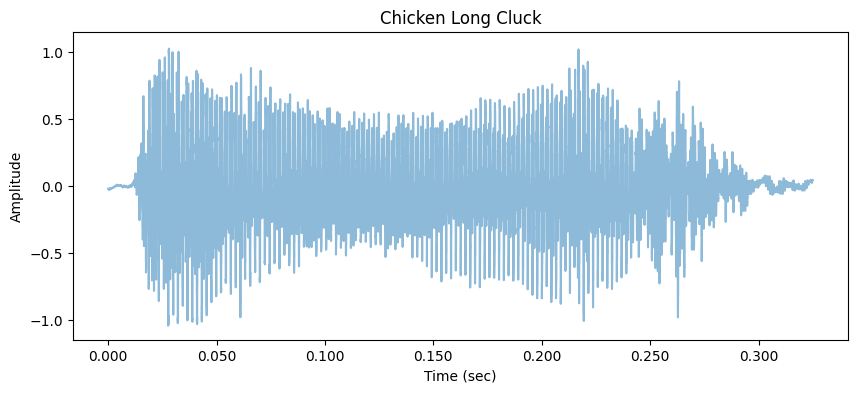

In [89]:
plotWaveform(chicken_vocals[9], 'Chicken Long Cluck')

In [84]:
# Check the number of samples in a short cluck
len(chicken_vocals[8])

2315

In [4]:
# Play the audio signal directly
# Audio(data=chicken_vocals[8], rate=SR)

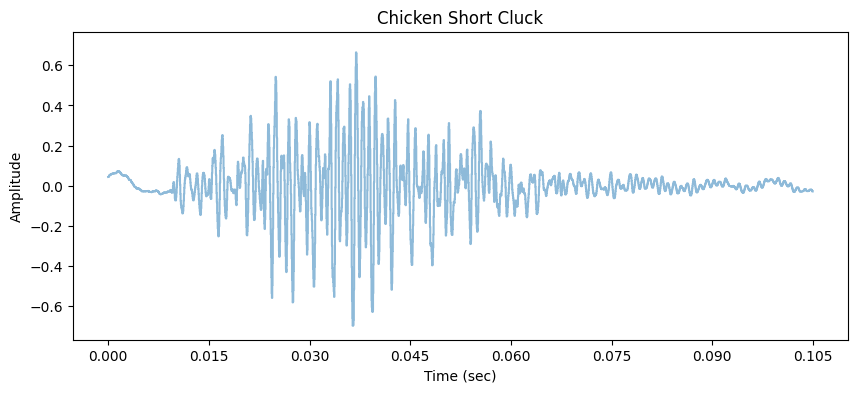

In [86]:
plotWaveform(chicken_vocals[8], 'Chicken Short Cluck')

In [99]:
exportArrayOfAudio(chicken_vocals, "chicken_egg_song", "cluck")